In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Load the dataset from the current folder or the parent folder.
df=pd.read_csv("world_cup_2026_matches.csv")

df.head()

,MatchID,Date,Stage,Group,Venue,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Winner,...,AwayPassAccuracy,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomeCorners,AwayCorners,Attendance,Referee,Advanced
0,1,2026-06-11,Group Stage,A,Dallas,Mexico,South Africa,0,0,Draw,...,8,0,4,1,0,0,1,44328,Ref 1,NaN
1,2,2026-06-11,Group Stage,B,Mexico City,South Korea,Czechia,1,4,Czechia,...,17,0,1,1,1,4,2,44110,Ref 2,NaN
2,3,2026-06-11,Group Stage,C,Toronto,Canada,Bosnia and Herzegovina,2,0,Canada,...,17,0,3,0,1,1,8,49213,Ref 3,NaN
3,4,2026-06-11,Group Stage,D,Los Angeles,Qatar,Switzerland,4,2,Qatar,...,18,0,3,1,1,10,5,40659,Ref 4,NaN
4,5,2026-06-11,Group Stage,E,Los Angeles,Brazil,Morocco,2,2,Draw,...,18,1,3,1,1,10,8,44392,Ref 5,NaN


In [14]:
# Check the size, columns, and missing values.
print("Rows and columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Rows and columns: (73, 28)

Columns:
['MatchID', 'Date', 'Stage', 'Group', 'Venue', 'HomeTeam', 'AwayTeam', 'HomeGoals', 'AwayGoals', 'Winner', 'GoalDifference', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomePossession', 'AwayPossession', 'HomePassAccuracy', 'AwayPassAccuracy', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards', 'HomeCorners', 'AwayCorners', 'Attendance', 'Referee', 'Advanced']

Missing values:
MatchID               0
Date                  0
Stage                 0
Group                 0
Venue                 0
HomeTeam              0
AwayTeam              0
HomeGoals             0
AwayGoals             0
Winner                0
GoalDifference        0
HomeShots             0
AwayShots             0
HomeShotsOnTarget     0
AwayShotsOnTarget     0
HomePossession        0
AwayPossession        0
HomePassAccuracy      0
AwayPassAccuracy      0
HomeYellowCards       0
AwayYellowCards       0
HomeRedCards          0
AwayRedCards

In [15]:
# Summary statistics for numeric columns.
df.describe()

,MatchID,HomeGoals,AwayGoals,GoalDifference,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomePossession,AwayPossession,HomePassAccuracy,AwayPassAccuracy,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomeCorners,AwayCorners,Attendance
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,37.000000,2.013699,2.027397,1.547945,12.739726,11.945205,5.465753,5.561644,48.712329,51.287671,85.493151,15.479452,2.095890,2.178082,0.561644,0.520548,5.054795,5.000000,58480.397260
std,21.217131,1.457673,1.443112,1.178996,4.708230,4.474900,2.764267,2.661382,8.477879,8.477879,6.344559,10.594954,1.510743,1.228622,0.499619,0.503035,3.370173,3.236081,13410.228252
min,1.000000,0.000000,0.000000,0.000000,5.000000,5.000000,1.000000,1.000000,35.000000,35.000000,75.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32537.000000
25%,19.000000,1.000000,1.000000,1.000000,9.000000,8.000000,3.000000,3.000000,41.000000,44.000000,81.000000,9.000000,1.000000,1.000000,0.000000,0.000000,2.000000,2.000000,48634.000000
50%,37.000000,2.000000,2.000000,1.000000,12.000000,12.000000,5.000000,5.000000,48.000000,52.000000,85.000000,15.000000,2.000000,2.000000,1.000000,1.000000,4.000000,6.000000,60318.000000
75%,55.000000,3.000000,3.000000,2.000000,17.000000,15.000000,8.000000,8.000000,56.000000,59.000000,91.000000,19.000000,4.000000,3.000000,1.000000,1.000000,8.000000,7.000000,71121.000000
max,73.000000,4.000000,4.000000,4.000000,20.000000,20.000000,10.000000,10.000000,65.000000,65.000000,95.000000,87.000000,4.000000,4.000000,1.000000,1.000000,10.000000,10.000000,79806.000000


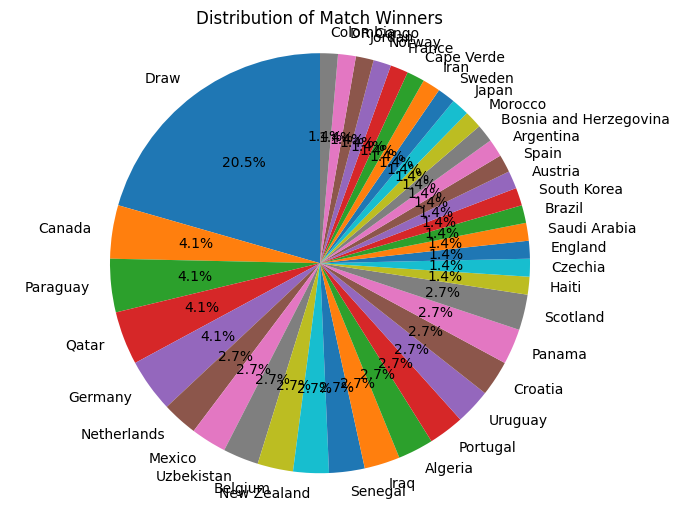

In [16]:
# Visualize how many matches each result category/team won.
winner_counts = df["Winner"].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(winner_counts, labels=winner_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Match Winners")
plt.axis("equal")
plt.show()

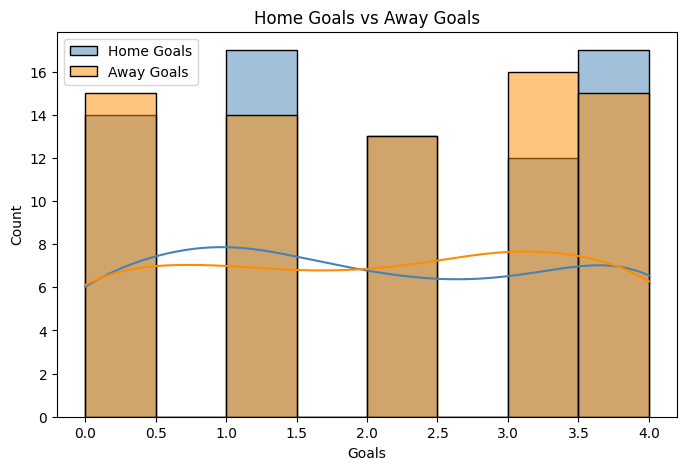

In [17]:
# Compare home goals and away goals.
plt.figure(figsize=(8, 5))
sns.histplot(df["HomeGoals"], color="steelblue", label="Home Goals", kde=True)
sns.histplot(df["AwayGoals"], color="darkorange", label="Away Goals", kde=True)
plt.title("Home Goals vs Away Goals")
plt.xlabel("Goals")
plt.legend()
plt.show()

In [18]:
# Maximum absolute scaling for numeric columns.
numeric_df = df.select_dtypes(include=np.number)
max_abs = numeric_df.abs().max()
scaled_df = numeric_df / max_abs
scaled_df.head()

,MatchID,HomeGoals,AwayGoals,GoalDifference,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomePossession,AwayPossession,HomePassAccuracy,AwayPassAccuracy,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomeCorners,AwayCorners,Attendance
0,0.013699,0.00,0.0,0.00,0.60,0.60,0.3,0.2,0.861538,0.676923,0.968421,0.091954,0.00,1.00,1.0,0.0,0.0,0.1,0.555447
1,0.027397,0.25,1.0,0.75,0.55,0.90,0.4,0.8,0.815385,0.723077,0.873684,0.195402,0.00,0.25,1.0,1.0,0.4,0.2,0.552715
2,0.041096,0.50,0.0,0.50,0.85,0.40,0.6,0.6,0.830769,0.707692,0.873684,0.195402,0.00,0.75,0.0,1.0,0.1,0.8,0.616658
3,0.054795,1.00,0.5,0.50,0.35,0.30,0.4,0.5,0.569231,0.969231,0.863158,0.206897,0.00,0.75,1.0,1.0,1.0,0.5,0.509473
4,0.068493,0.50,0.5,0.00,0.65,0.35,1.0,0.3,0.800000,0.738462,0.863158,0.206897,0.25,0.75,1.0,1.0,1.0,0.8,0.556249


In [19]:
# Select features for predicting HomeGoals.
# GoalDifference and Winner are excluded because they directly depend on the final score.
features = [
    "HomeShots", "AwayShots",
    "HomeShotsOnTarget", "AwayShotsOnTarget",
    "HomePossession", "AwayPossession",
    "HomePassAccuracy", "AwayPassAccuracy",
    "HomeYellowCards", "AwayYellowCards",
    "HomeRedCards", "AwayRedCards",
    "HomeCorners", "AwayCorners",
    "Attendance"
]

X = df[features]
y = df["HomeGoals"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 58
Testing rows: 15


In [20]:
# Train the Linear Regression model.
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 3))
print("R2 Score:", round(r2, 3))

Mean Squared Error: 3.518
R2 Score: -0.706


In [21]:
# Show actual vs predicted home goals.
results = pd.DataFrame({
    "Actual Home Goals": y_test.values,
    "Predicted Home Goals": np.round(y_pred, 2)
})

results.head(10)

,Actual Home Goals,Predicted Home Goals
0,2,2.15
1,0,2.61
2,1,2.16
3,0,1.85
4,4,1.40
5,0,3.30
6,2,1.63
7,3,0.93
8,2,2.36
9,4,1.26


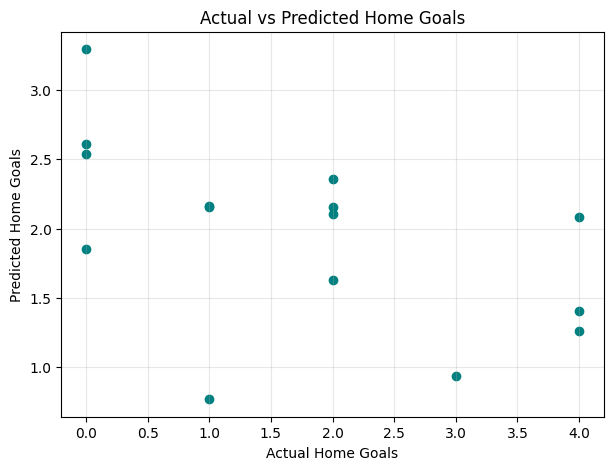

In [22]:
# Plot actual vs predicted values.
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color="teal")
plt.xlabel("Actual Home Goals")
plt.ylabel("Predicted Home Goals")
plt.title("Actual vs Predicted Home Goals")
plt.grid(True, alpha=0.3)
plt.show()